# Data Preprocessing & Feature Engineering

In [2]:
import pandas as pd

In [3]:
col_names = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root","num_file_creations",
"num_shells","num_access_files","num_outbound_cmds","is_host_login",
"is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
"rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
"srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

In [4]:
train = pd.read_csv("../data/raw/KDDTrain+.txt", names=col_names)
test = pd.read_csv("../data/raw/KDDTest+.txt", names=col_names)

In [5]:
train['label'] = train['label'].apply(lambda x: 'attack' if x != 'normal' else 'normal')
test['label'] = test['label'].apply(lambda x: 'attack' if x != 'normal' else 'normal')

In [6]:
train.select_dtypes(include=['object', 'string']).columns

Index(['protocol_type', 'service', 'flag', 'label'], dtype='str')

In [7]:
train = pd.get_dummies(train, columns=['protocol_type', 'service', 'flag'])
test = pd.get_dummies(test, columns=['protocol_type', 'service', 'flag'])

In [8]:
train.shape

(125973, 124)

In [9]:
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [10]:
print ("Train shape: ", train.shape)
print ("Test shape: ", test.shape)

Train shape:  (125973, 124)
Test shape:  (22544, 124)


In [11]:
train['label'] = train['label'].map({'normal': 0, 'attack': 1})
test['label'] = test['label'].map({'normal': 0, 'attack': 1})

In [12]:
train['label'].unique()

array([0, 1])

In [13]:
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

In [14]:
print(X_train.shape)
print(y_train.shape)

(125973, 123)
(125973,)


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [18]:
X_train_scaled[:5]

array([[-1.10249223e-01, -7.67859947e-03, -4.91864438e-03,
        -1.40888118e-02, -8.94864220e-02, -7.73598503e-03,
        -9.50756715e-02, -2.70228184e-02, -8.09261819e-01,
        -1.16636426e-02, -3.66518691e-02, -2.44365073e-02,
        -1.23851504e-02, -2.61800242e-02, -1.86098963e-02,
        -4.12211976e-02,  0.00000000e+00, -2.81749392e-03,
        -9.75309440e-02, -7.17045492e-01, -3.54342850e-01,
        -6.37209268e-01, -6.31929033e-01, -3.74362240e-01,
        -3.74431603e-01,  7.71283106e-01, -3.49683031e-01,
        -3.74559704e-01, -3.24063093e-01, -8.18889977e-01,
        -7.82366826e-01, -2.80281676e-01,  6.99722578e-02,
        -2.89103400e-01, -6.39531905e-01, -6.24870800e-01,
        -2.24532415e-01, -3.76387026e-01,  2.16426331e-01,
        -2.65429041e-01,  4.76175266e-01, -3.67554641e-01,
        -3.85571256e-02, -2.40795610e-02, -8.30053118e-02,
        -3.98455393e-03, -8.74008009e-02, -7.52866148e-02,
        -7.65558238e-02, -6.59175417e-02, -6.70020535e-0

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = model.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8066004258339248


In [22]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[8897,  814],
       [3546, 9287]])

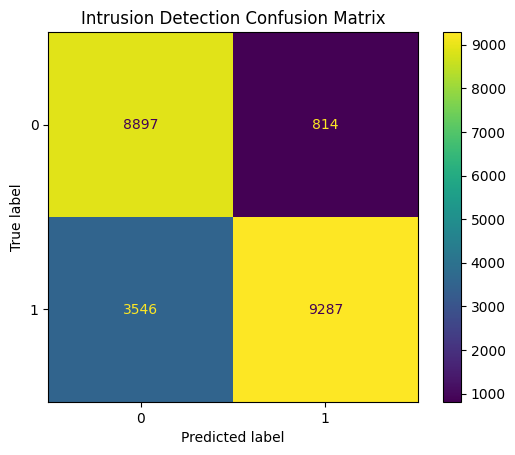

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Intrusion Detection Confusion Matrix")
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy: ", rf_accuracy)

Random Forest Accuracy:  0.7576738821859474


In [26]:
print(X_train.shape)
print(X_test.shape)

(125973, 123)
(22544, 123)


In [27]:
(X_train.columns == X_test.columns).all()

np.True_

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8035397444996452


In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8005234208658624


In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [34]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [35]:
import numpy as np
y_pred_adjusted = np.where(y_probs >  0.3, 1, 0)

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      9711
           1       0.97      0.84      0.90     12833

    accuracy                           0.89     22544
   macro avg       0.90      0.90      0.89     22544
weighted avg       0.91      0.89      0.89     22544



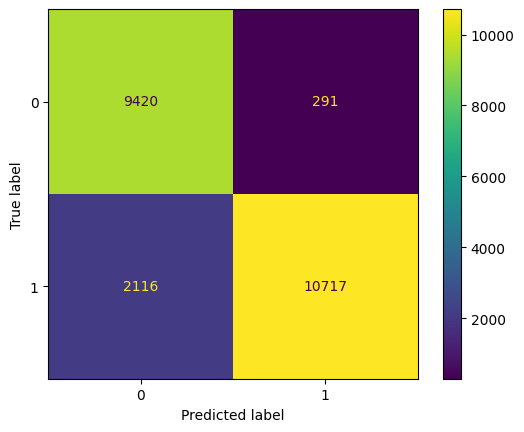

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_adjusted)

In [38]:
import joblib
joblib.dump(rf_model, "../models/intrusion_detection_model.pkl")

['../models/intrusion_detection_model.pkl']

In [39]:
plt.savefig("../visuals/confusion_matrix.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

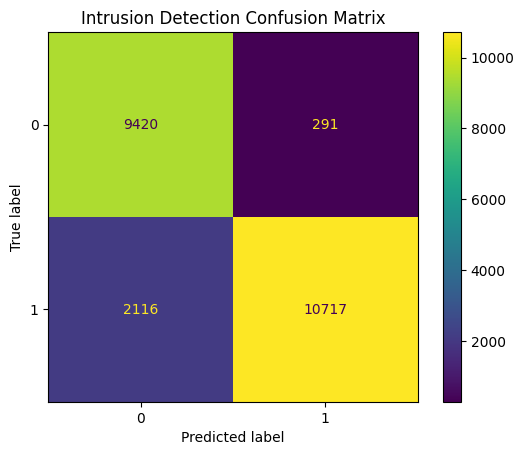

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_adjusted)

plt.title("Intrusion Detection Confusion Matrix")

plt.savefig("../visuals/confusion_matrix.png", bbox_inches="tight")

plt.show()

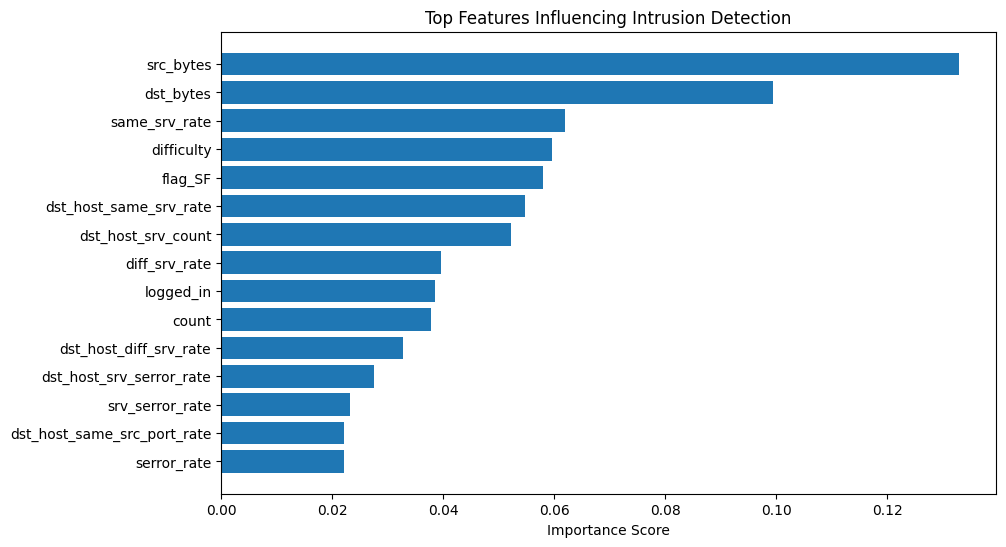

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

#Get feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

#Create dataframe
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

#Sort and take top 15
top_features = feat_imp.sort_values(by="Importance", ascending=False).head(15)

#Plot
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Intrusion Detection")
plt.xlabel("Importance Score")

plt.savefig("../visuals/feature_importance.png", bbox_inches="tight")
plt.show()

In [42]:
import joblib

joblib.dump(rf_model, "../models/intrusion_detection_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [43]:
X_test[:10].to_csv("test_sample.csv", index=False)